[2026-07-30 17:57:26] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-30 17:57:46] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-30 17:57:46] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-30 17:57:49] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-30 17:57:49] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-30 17:57:49] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-30 17:57:49] [info     ] ========== 数据检查 ==========
[2026-07-30 17:57:49] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg

时段,IC
2024-01-15~2024-02-08,-0.0114
2024-09-24~2024-10-08,0.0345

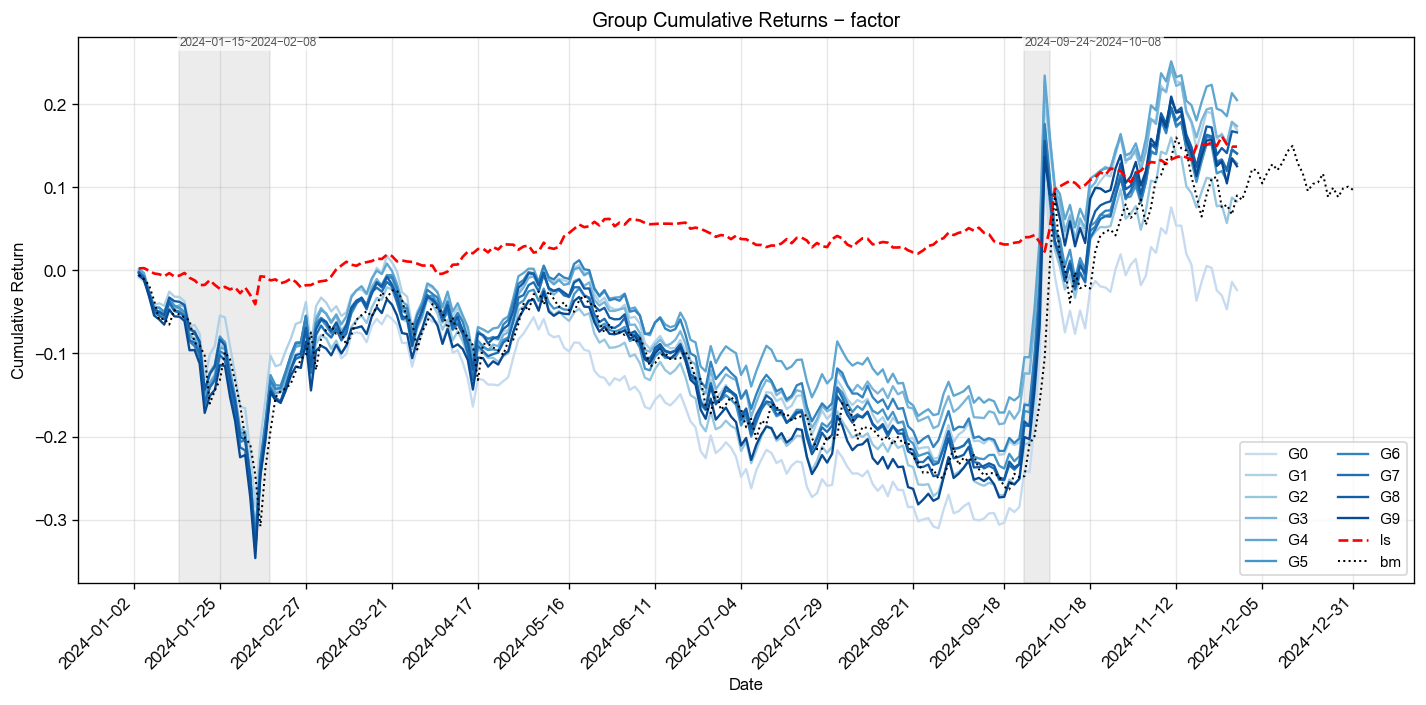
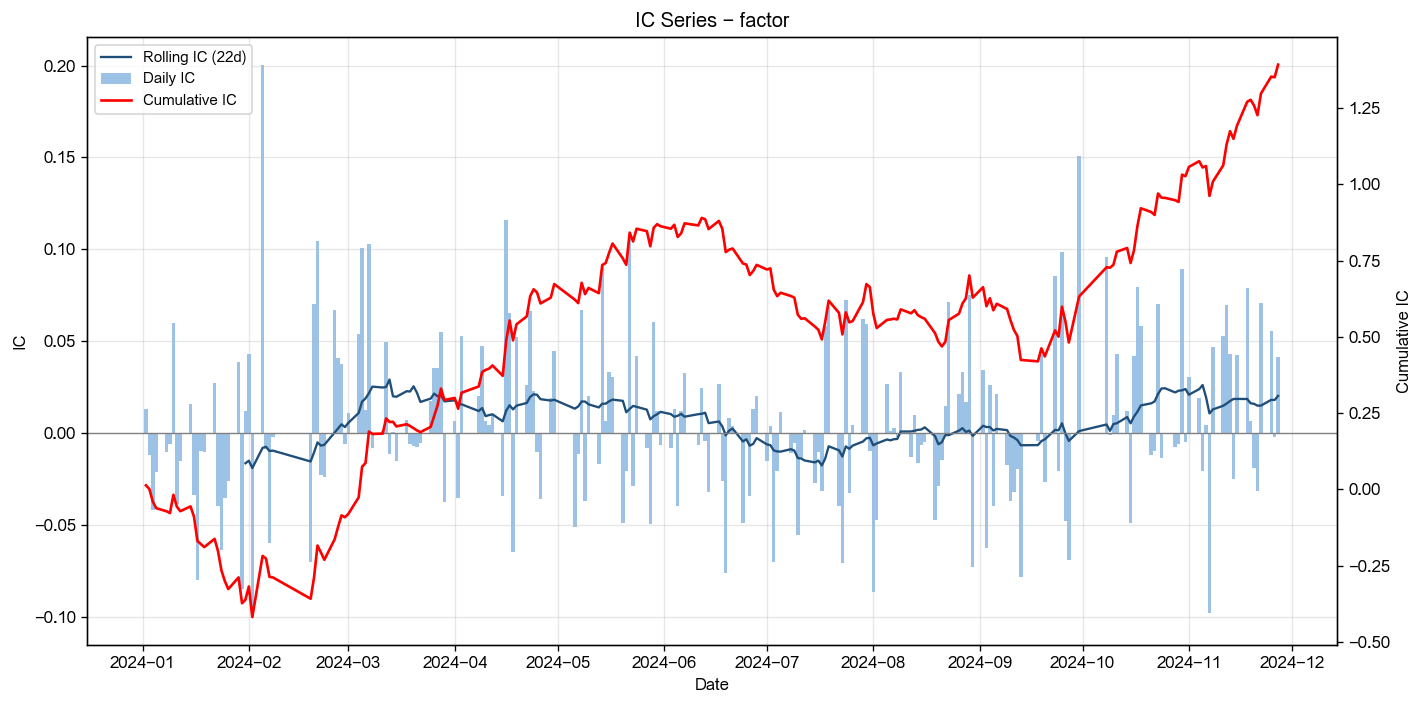
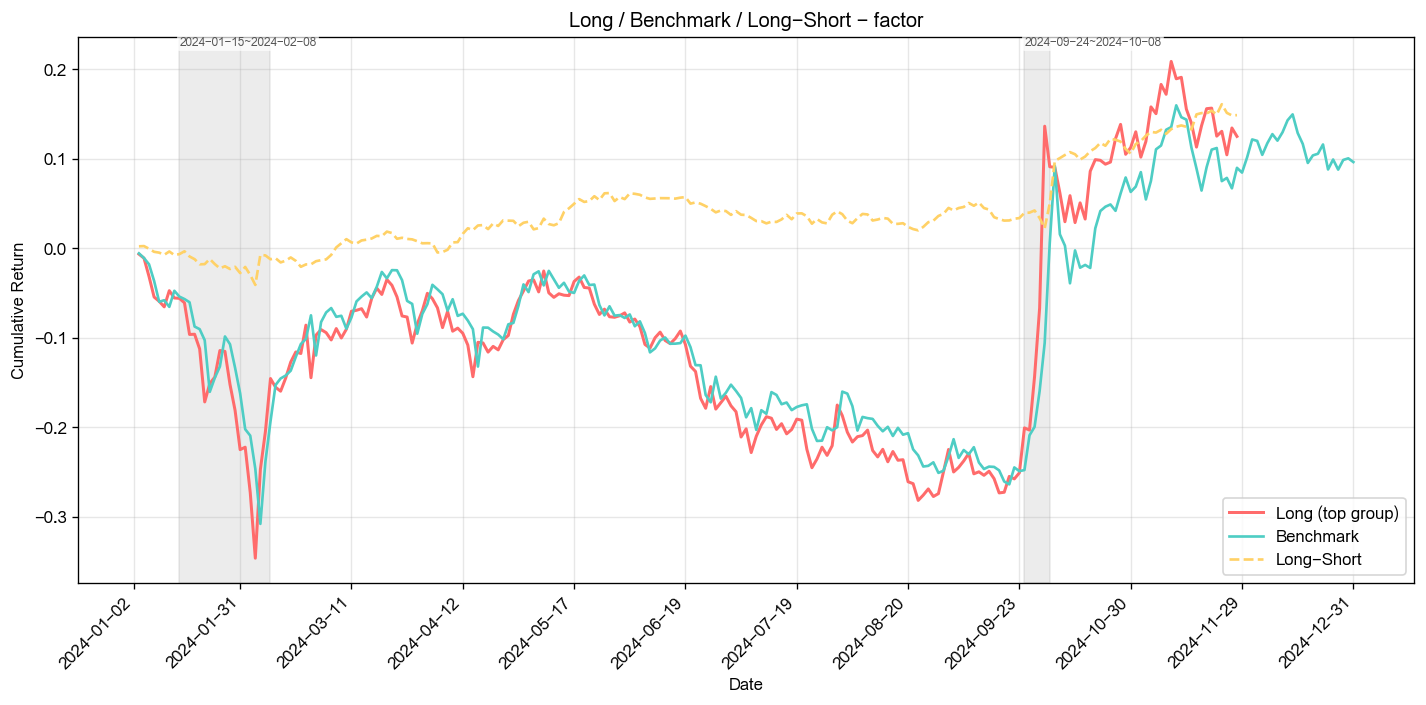
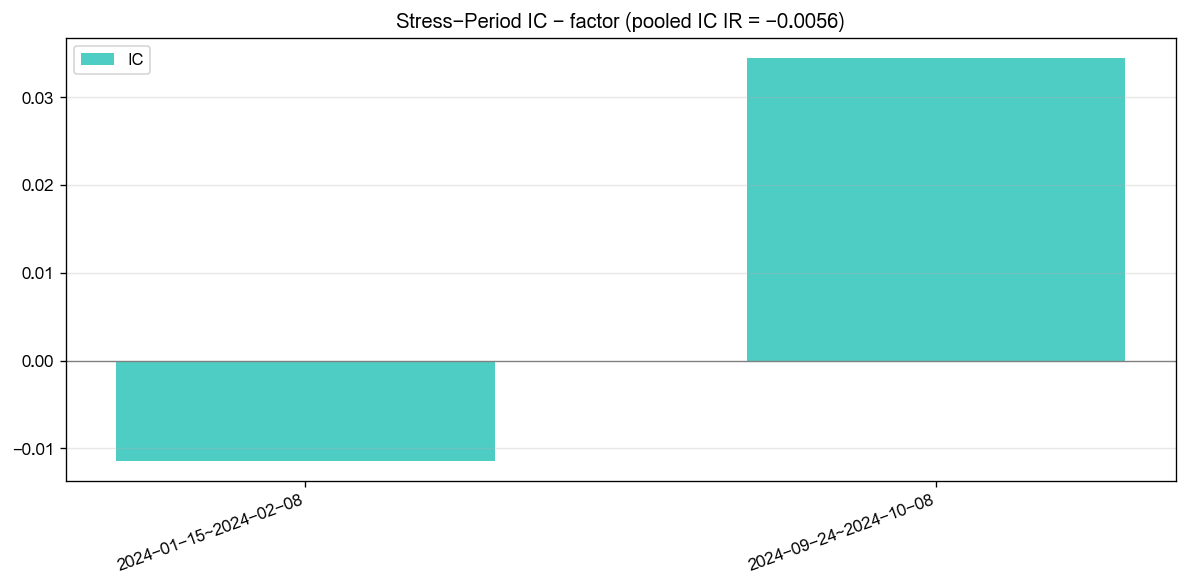
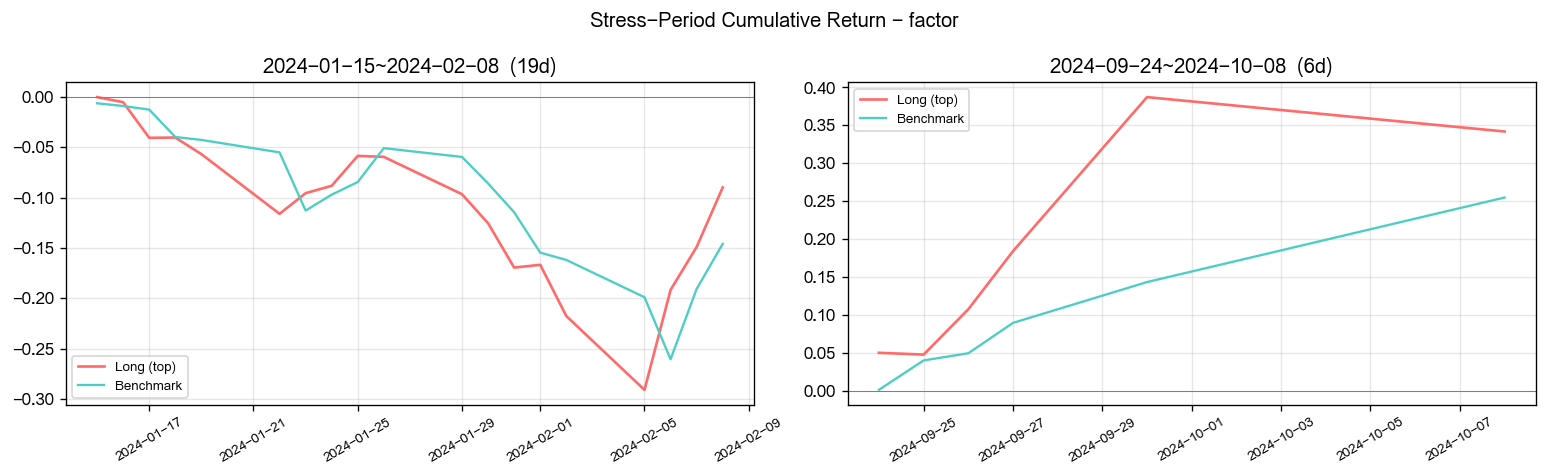

[2026-07-30 17:58:03] [info     ] ========== 因子池回归 ==========
[2026-07-30 17:58:03] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-30 17:58:04] [info     ] 获取收益率数据, 耗时: 1.2776 秒
[2026-07-30 17:58:05] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.0604 秒
[2026-07-30 17:58:05] [info     ] 统计 回归结果, 耗时: 0.0872 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9410,0.0446,0.0230,1.0000
2,amount,1.7234,0.0185,0.0107,1.0000
3,netflow_amount_main,1.5151,0.0253,0.0167,1.0000
4,gross_profit_rate_ttm,1.5041,0.0069,0.0046,1.0000
5,net_profit_rate_ttm,1.4516,0.0040,0.0027,0.8000
6,cci_14,1.4230,0.0343,0.0241,1.0000
7,bias_20,1.4192,0.0292,0.0206,0.9000
8,pb,1.4187,0.0097,0.0068,1.0000
9,netflow_amount_rate_main,1.3942,0.0093,0.0067,1.0000
10,pe_ttm,1.3033,0.0029,0.0022,0.9000

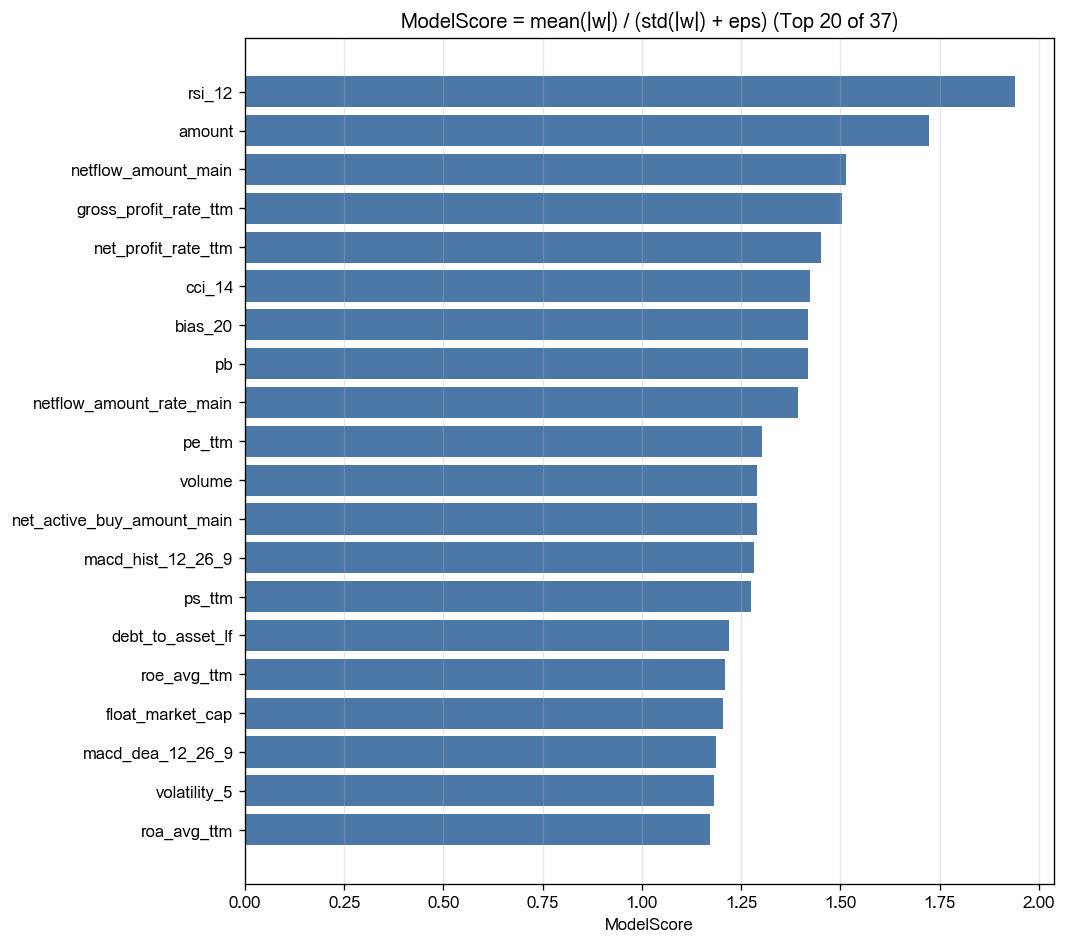
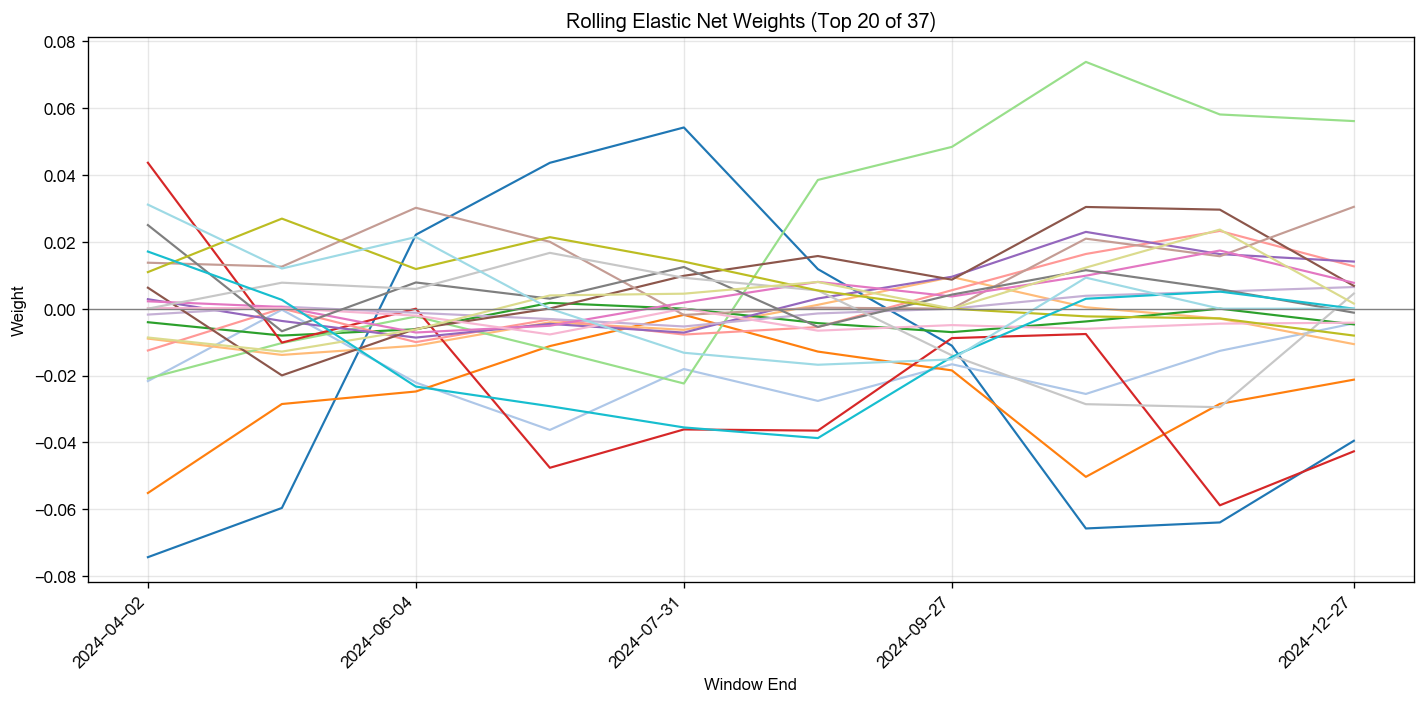
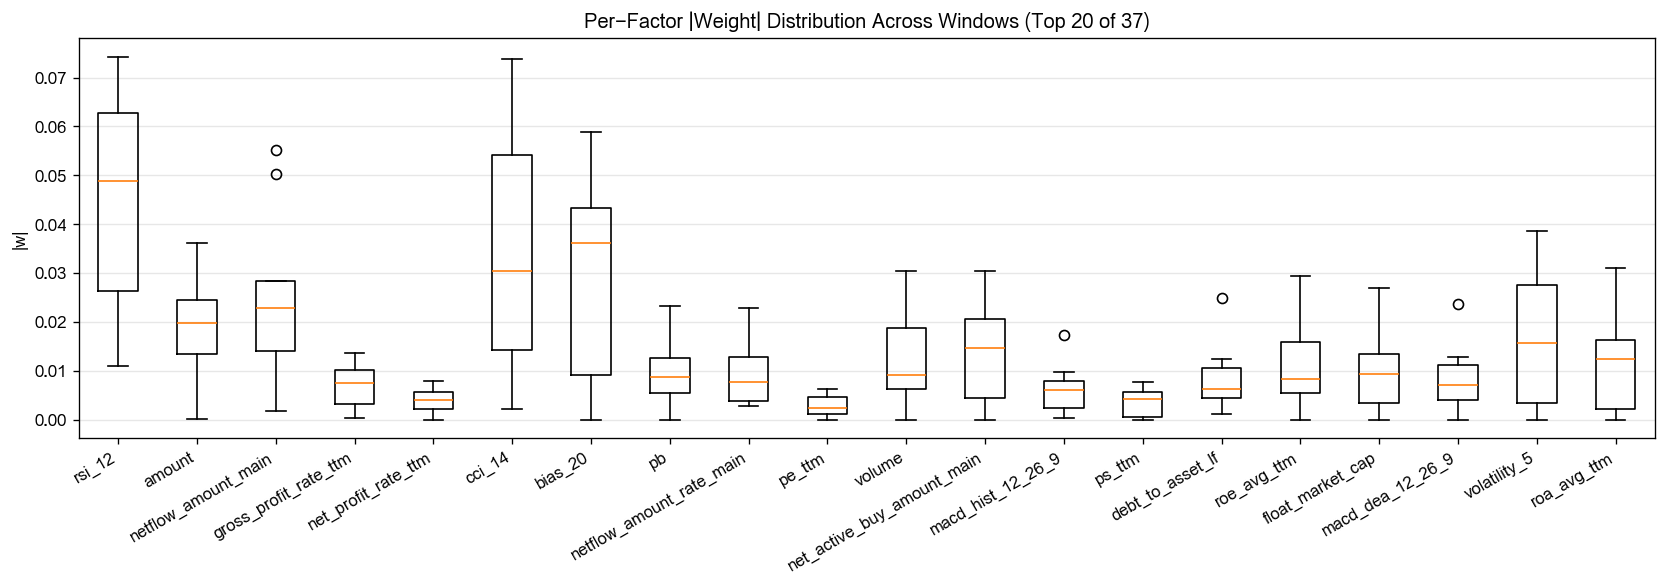
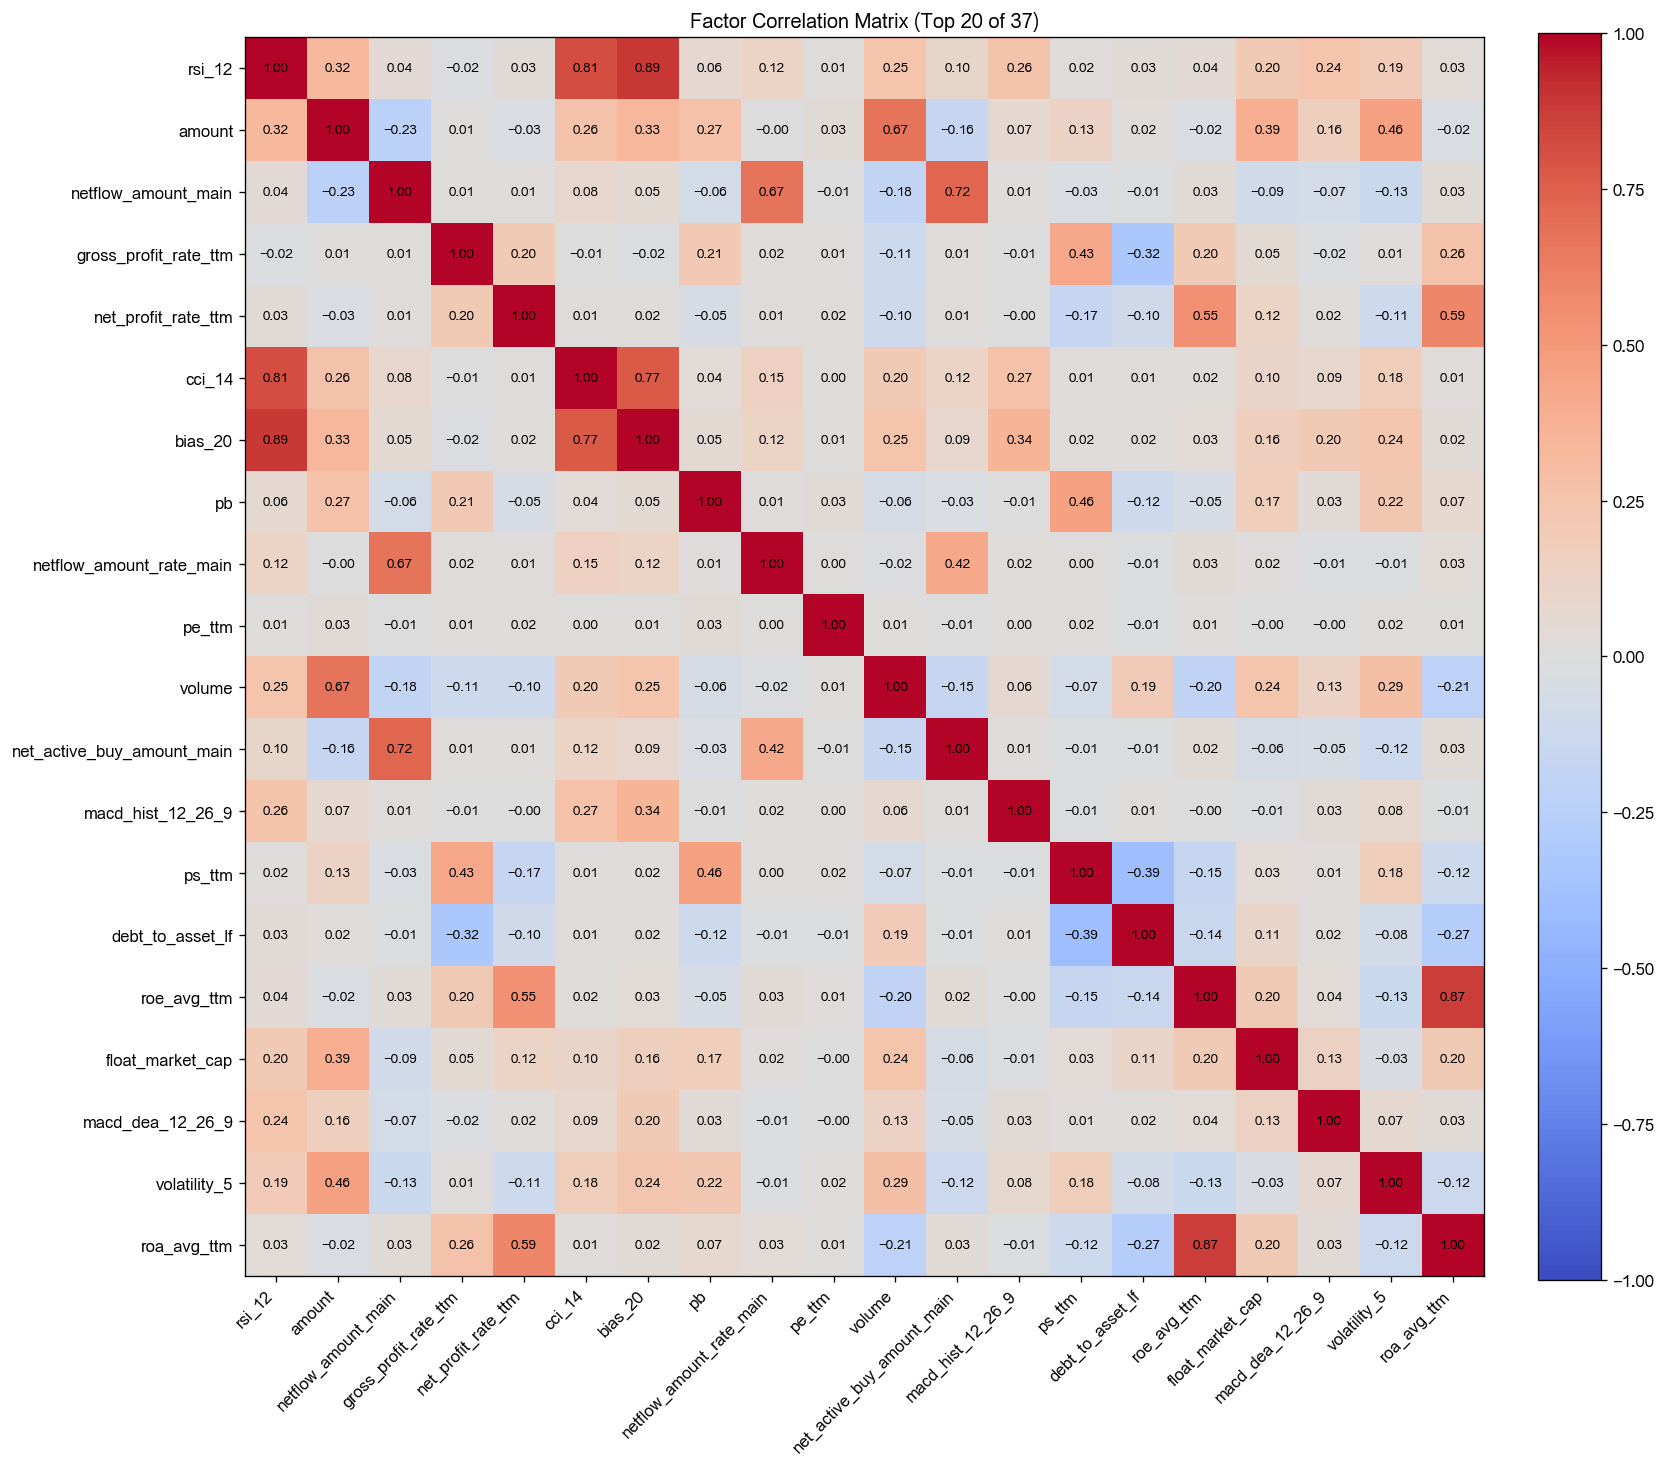

[2026-07-30 17:58:08] [warning  ] 返回的Outputs实例(size=35318289) 大于 64K, 将不会被缓存
[2026-07-30 17:58:08] [info     ] bigalpha_eval.v4 运行完成 [18.794s].

========== 可复制给大模型的 DMI 因子回测结果（JSON） ==========
{
  "factor_name": "DMI_stock_intraday",
  "factor_logic": {
    "bar_frequency": "5分钟",
    "dmi_period": 12,
    "tail_bars": 12,
    "direction": "因子越大，股票排名越靠前"
  },
  "sample_period": {
    "start": "2024-01-01 00:00:00",
    "end": "2024-12-31 23:59:59"
  },
  "factor_data_stats": {
    "rows": 242000,
    "trading_days": 242,
    "instruments": 1206,
    "factor_mean": 0.0054938472922602686,
    "factor_std": 0.13104727770018434,
    "factor_min": -0.9002905972558544,
    "factor_max": 1.0,
    "zero_ratio": 0.010615702479338842
  },
  "factor_analyze": {
    "ic_mean": 0.006389774472265013,
    "ic_ir": 0.1378960887538402,
    "sharpe_ratio": 1.3516553631975206,
    "stress_ic_ir": -0.005586217548732801
  },
  "per_factor_scores": [
    {
      "factor": "rsi_12",
      "model_score": 1.94

In [1]:
def main(datasources, start_date, end_date):
    """
    构建适用于中证 1000 截面选股的原始 DMI 日内反转因子。

    评测时平台会自动替换 datasources / start_date / end_date 并调用本函数。
    返回值必须且仅包含 date、instrument、factor 三列，且因子值越大排名越靠前。
    """
    import numpy as np
    import pandas as pd
    import dai

    # 分钟表在公榜、私榜会切换物理表名，必须从 datasources 动态取得。
    bar1m = datasources["bar1m"]

    # V2 仅反号后 IC/ICIR/Sharpe 均转正，证明 A 股截面上应采用短周期反转方向；
    # 但 IC Mean 仅 0.0025，说明 CTA 版的方向平衡、加速度和收盘位置混合仍含较多噪声。
    # V3 回到 Excel 原始 DMI：TR/ATR -> +DI/-DI -> DX -> ADX，并使用 Wilder 几何衰减平滑。
    # 14 根 5 分钟 bar 是经典 DMI 周期；因指标自身已平滑，只聚合最后 6 根（30 分钟）。
    DMI_PERIOD = 14
    TAIL_BARS = 6
    MIN_5M_BARS = 42
    MIN_TAIL_VALID = 5
    FACTOR_SIGN = -1.0
    WILDER_ALPHA = 1.0 / DMI_PERIOD
    WILDER_DECAY = 1.0 - WILDER_ALPHA
    WILDER_WEIGHT_SUM = (1.0 - WILDER_DECAY ** DMI_PERIOD) / WILDER_ALPHA
    EPS = 1e-12

    # 本因子只在单个交易日内滚动并在每日开盘重置，因此不依赖评估区间之前的数据。
    # 这样可主动排除隔夜跳空和除权日价格跳变对分钟 DM 的污染，也适合私榜逐日增量计算。
    # DMI 方向比率对同日 OHLC 同乘一个复权因子具有尺度不变性，因此无需重复处理 adjust_factor。
    sql = f"""
    WITH cte_valid_1m AS (
        SELECT
            date,
            instrument,
            instrument_id,
            strftime(date, '%Y-%m-%d') AS trading_day,
            CASE
                -- 将上午 09:31~11:30 映射为 1~120，下午 13:01~15:00 映射为 121~240。
                WHEN strftime(date, '%H:%M:%S') <= '11:30:00'
                THEN hour(date) * 60 + minute(date) - 570
                ELSE hour(date) * 60 + minute(date) - 660
            END AS minute_number,
            high,
            low,
            close
        FROM {bar1m}
        -- 仅剔除无法形成有效 K 线的记录；停牌或无方向波动的股票后续会得到中性值 0。
        WHERE high > 0
          AND low > 0
          AND close > 0
          AND high >= low
          -- date 为 bar 结束时刻；只保留 A 股连续竞价的 240 根分钟 bar，排除集合竞价。
          AND (
              strftime(date, '%H:%M:%S') BETWEEN '09:31:00' AND '11:30:00'
              OR strftime(date, '%H:%M:%S') BETWEEN '13:01:00' AND '15:00:00'
          )
    ),
    cte_5m_raw AS (
        SELECT
            instrument_id,
            instrument,
            trading_day,
            CAST(floor((minute_number - 1) / 5) AS BIGINT) AS bucket_5m,
            max(date) AS bar_time,
            max(high) AS high_5m,
            min(low) AS low_5m,
            last(close ORDER BY date) AS close_5m,
            count(*) AS minute_count
        FROM cte_valid_1m
        GROUP BY
            instrument_id,
            instrument,
            trading_day,
            CAST(floor((minute_number - 1) / 5) AS BIGINT)
    ),
    cte_5m AS (
        SELECT
            instrument_id, instrument, trading_day, bar_time,
            high_5m, low_5m, close_5m
        FROM cte_5m_raw
        -- 若源数据尾部偶有缺分钟，保留至少 3 条记录的最后一个桶。
        WHERE minute_count >= 3
    ),
    cte_previous AS (
        SELECT
            *,
            lag(high_5m, 1) OVER (
                PARTITION BY instrument_id, trading_day ORDER BY bar_time
            ) AS previous_high,
            lag(low_5m, 1) OVER (
                PARTITION BY instrument_id, trading_day ORDER BY bar_time
            ) AS previous_low,
            lag(close_5m, 1) OVER (
                PARTITION BY instrument_id, trading_day ORDER BY bar_time
            ) AS previous_close,
            row_number() OVER (
                PARTITION BY instrument_id, trading_day ORDER BY bar_time
            ) AS bar_number
        FROM cte_5m
    ),
    cte_move AS (
        SELECT
            *,
            high_5m - previous_high AS up_move,
            previous_low - low_5m AS down_move,
            -- 原始 DMI 的真实波幅：纳入相对上一根收盘价的跳变。
            CASE
                WHEN previous_close IS NULL THEN NULL
                ELSE greatest(
                    high_5m - low_5m,
                    abs(high_5m - previous_close),
                    abs(low_5m - previous_close)
                )
            END AS true_range
        FROM cte_previous
    ),
    cte_dm AS (
        SELECT
            *,
            -- 经典 DMI 互斥方向移动：同一根 bar 只保留较强的一侧。
            CASE
                WHEN previous_high IS NULL OR previous_low IS NULL THEN NULL
                WHEN up_move > down_move AND up_move > 0 THEN up_move
                ELSE 0.0
            END AS plus_dm,
            CASE
                WHEN previous_high IS NULL OR previous_low IS NULL THEN NULL
                WHEN down_move > up_move AND down_move > 0 THEN down_move
                ELSE 0.0
            END AS minus_dm
        FROM cte_move
    ),
    cte_wilder_dm AS (
        SELECT
            *,
            -- 用几何权重窗口实现 Wilder 平滑；最新 bar 权重为 1，向前每根乘 decay。
            power({WILDER_DECAY}, bar_number) * sum(
                plus_dm * power({WILDER_DECAY}, -bar_number)
            ) OVER (
                PARTITION BY instrument_id, trading_day ORDER BY bar_time
                ROWS BETWEEN {DMI_PERIOD - 1} PRECEDING AND CURRENT ROW
            ) AS plus_dm_ws,
            power({WILDER_DECAY}, bar_number) * sum(
                minus_dm * power({WILDER_DECAY}, -bar_number)
            ) OVER (
                PARTITION BY instrument_id, trading_day ORDER BY bar_time
                ROWS BETWEEN {DMI_PERIOD - 1} PRECEDING AND CURRENT ROW
            ) AS minus_dm_ws,
            power({WILDER_DECAY}, bar_number) * sum(
                true_range * power({WILDER_DECAY}, -bar_number)
            ) OVER (
                PARTITION BY instrument_id, trading_day ORDER BY bar_time
                ROWS BETWEEN {DMI_PERIOD - 1} PRECEDING AND CURRENT ROW
            ) AS atr_ws,
            count(true_range) OVER (
                PARTITION BY instrument_id, trading_day ORDER BY bar_time
                ROWS BETWEEN {DMI_PERIOD - 1} PRECEDING AND CURRENT ROW
            ) AS dm_observations
        FROM cte_dm
    ),
    cte_di AS (
        SELECT
            *,
            CASE
                WHEN dm_observations >= {DMI_PERIOD} AND atr_ws > {EPS}
                THEN 100.0 * plus_dm_ws / atr_ws
                ELSE NULL
            END AS plus_di,
            CASE
                WHEN dm_observations >= {DMI_PERIOD} AND atr_ws > {EPS}
                THEN 100.0 * minus_dm_ws / atr_ws
                ELSE NULL
            END AS minus_di
        FROM cte_wilder_dm
    ),
    cte_dx AS (
        SELECT
            *,
            CASE
                WHEN plus_di IS NULL OR minus_di IS NULL THEN NULL
                WHEN plus_di + minus_di > {EPS}
                THEN 100.0 * abs(plus_di - minus_di) / (plus_di + minus_di)
                ELSE 0.0
            END AS dx
        FROM cte_di
    ),
    cte_wilder_adx AS (
        SELECT
            *,
            power({WILDER_DECAY}, bar_number) * sum(
                dx * power({WILDER_DECAY}, -bar_number)
            ) OVER (
                PARTITION BY instrument_id, trading_day ORDER BY bar_time
                ROWS BETWEEN {DMI_PERIOD - 1} PRECEDING AND CURRENT ROW
            ) / {WILDER_WEIGHT_SUM} AS adx,
            count(dx) OVER (
                PARTITION BY instrument_id, trading_day ORDER BY bar_time
                ROWS BETWEEN {DMI_PERIOD - 1} PRECEDING AND CURRENT ROW
            ) AS adx_observations
        FROM cte_dx
    ),
    cte_signed_dmi AS (
        SELECT
            *,
            CASE
                WHEN adx_observations >= {DMI_PERIOD}
                 AND plus_di IS NOT NULL
                 AND minus_di IS NOT NULL
                THEN greatest(
                    -1.0,
                    least(
                        1.0,
                        -- 保留 (+DI - -DI)/100 的 ATR 标准化幅度；ADX 仅作温和置信度门控。
                        ((plus_di - minus_di) / 100.0)
                        * (0.5 + 0.5 * least(1.0, greatest(0.0, adx / 100.0)))
                    )
                )
                ELSE NULL
            END AS signed_dmi
        FROM cte_wilder_adx
    ),
    cte_ranked AS (
        SELECT
            *,
            row_number() OVER (
                PARTITION BY instrument_id, trading_day ORDER BY bar_time DESC
            ) AS reverse_bar_number
        FROM cte_signed_dmi
    ),
    cte_daily AS (
        SELECT
            trading_day,
            instrument,
            count(*) AS bar_count,
            max(bar_time) AS last_bar_time,
            count(CASE
                WHEN reverse_bar_number BETWEEN 1 AND {TAIL_BARS}
                THEN signed_dmi
            END) AS late_valid_count,

            -- 指标自身已经 Wilder 平滑；尾盘仅做 30 分钟线性加权，越接近收盘权重越高。
            sum(CASE
                WHEN reverse_bar_number BETWEEN 1 AND {TAIL_BARS}
                 AND signed_dmi IS NOT NULL
                THEN ({TAIL_BARS + 1} - reverse_bar_number) * signed_dmi
                ELSE 0.0
            END) AS late_dmi_weighted_sum,
            sum(CASE
                WHEN reverse_bar_number BETWEEN 1 AND {TAIL_BARS}
                 AND signed_dmi IS NOT NULL
                THEN {TAIL_BARS + 1} - reverse_bar_number
                ELSE 0.0
            END) AS late_dmi_weight_sum
        FROM cte_ranked
        GROUP BY trading_day, instrument
    ),
    cte_factor AS (
        SELECT
            trading_day,
            instrument,
            CASE
                WHEN bar_count >= {MIN_5M_BARS}
                 AND strftime(last_bar_time, '%H:%M:%S') >= '14:55:00'
                 AND late_valid_count >= {MIN_TAIL_VALID}
                 AND late_dmi_weight_sum > {EPS}
                -- 先保留原始有符号 DMI（上涨为正、下跌为负），最终输出时统一反号。
                THEN late_dmi_weighted_sum / late_dmi_weight_sum
                -- 残缺交易日、停牌或历史不足时给中性值，保证覆盖度而不制造方向。
                ELSE 0.0
            END AS raw_factor
        FROM cte_daily
    )
    SELECT
        CAST(trading_day AS DATETIME) AS date,
        instrument,
        -- V3 沿用 V2 已验证的反转方向：日内下跌 DMI 越强，因子排名越靠前。
        CASE
            WHEN isfinite(raw_factor) THEN {FACTOR_SIGN} * raw_factor
            ELSE 0.0
        END AS factor
    FROM cte_factor
    """

    # 计算区间内的分钟数据；compression=True 可显著降低 instrument 列内存占用。
    factor_df = dai.query(
        sql,
        filters={"date": [start_date, end_date]},
        compression=True,
    ).df()

    # 动态对齐历史中证 1000 成分股。以股票池为左表，缺少有效分钟数据的股票填 0，
    # 从而保证交易日完整性和覆盖度；0 表示没有可确认的多空方向。
    stock_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
        compression=True,
    ).df()

    factor_df = factor_df[["date", "instrument", "factor"]].copy()
    stock_pool = stock_pool[["date", "instrument"]].copy()

    # 统一到交易日 00:00:00，避免分钟聚合日期与股票池日期因时间部分不同而无法连接。
    factor_df["date"] = pd.to_datetime(factor_df["date"]).dt.normalize()
    stock_pool["date"] = pd.to_datetime(stock_pool["date"]).dt.normalize()
    factor_df["instrument"] = factor_df["instrument"].astype(str)
    stock_pool["instrument"] = stock_pool["instrument"].astype(str)

    factor_df = factor_df.drop_duplicates(["date", "instrument"], keep="last")
    stock_pool = stock_pool.drop_duplicates(["date", "instrument"], keep="last")
    result = pd.merge(
        stock_pool,
        factor_df,
        how="left",
        on=["date", "instrument"],
        validate="one_to_one",
    )

    # 双重清理非有限值，确保通过平台的 inf / NaN 校验。
    result["factor"] = (
        pd.to_numeric(result["factor"], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .astype(float)
    )

    # 防御性裁剪到评测区间，并严格限定列名、列顺序和唯一键。
    start_day = pd.to_datetime(start_date).normalize()
    end_day = pd.to_datetime(end_date).normalize()
    result = result[(result["date"] >= start_day) & (result["date"] <= end_day)]
    result = result[["date", "instrument", "factor"]]
    df = result.sort_values(["date", "instrument"]).reset_index(drop=True)
    return df



if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估，您可以换成自己的因子库
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统：
    # process_pools=False 表示不对因子库再做预处理（bigalpha_2026_factorlib 已处理过）
    # show=True 表示画出评估图表
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )


# if __name__ == "__main__":
#     from bigmodule import M
#     import dai
#     import structlog

#     logger = structlog.get_logger()

#     # 本地平台自测映射；正式评测时由平台注入并自动切换公榜/私榜物理表。
#     datasources = {"bar1m": "bigalpha_2026_stock_bar1m"}
#     start_date = "2024-01-01 00:00:00"
#     end_date = "2024-12-31 23:59:59"

#     logger.info(f"计算 DMI 股票因子，区间：{start_date} ~ {end_date}")
#     factor_data = main(datasources, start_date, end_date)

#     logger.info(f"读取平台因子库，区间：{start_date} ~ {end_date}")
#     factor_pool = dai.query(
#         "SELECT * FROM bigalpha_2026_factorlib",
#         filters={"date": [start_date, end_date]},
#     ).df()

#     result = M.bigalpha_eval._latest(
#         factor_data=factor_data,
#         factor_pool=factor_pool,
#         process_pools=False,
#         show=True,
#     )

    # ===== 打印可直接复制给大模型的回测摘要 =====
    # 比赛平台只会提取并执行 main()；本段位于 main() 外，只用于本地研究，不会影响正式提交。
    # 官方评估对象通常将详细结果放在 _result / _detail 中；下面同时兼容字典、DataFrame 和对象属性。
    import json
    import math

    def _read_field(obj, field):
        """兼容字典键和对象属性两种结果结构。"""
        if obj is None:
            return None
        if isinstance(obj, dict):
            return obj.get(field)
        return getattr(obj, field, None)

    def _find_section(field):
        """从评估返回值、_result、_detail 中寻找指定结果块。"""
        containers = [
            result,
            getattr(result, "_result", None),
            getattr(result, "_detail", None),
        ]
        if isinstance(result, dict):
            containers.extend([result.get("_result"), result.get("_detail")])

        # 先检查顶层，再检查一层嵌套，兼容平台版本差异。
        for container in containers:
            value = _read_field(container, field)
            if value is not None:
                return value
        for container in containers:
            if isinstance(container, dict):
                for child in container.values():
                    value = _read_field(child, field)
                    if value is not None:
                        return value
        return None

    def _json_ready(value, max_rows=100):
        """将常见平台对象转成紧凑、合法且方便复制的 JSON 数据。"""
        if value is None or isinstance(value, (str, bool, int)):
            return value
        if isinstance(value, float):
            return value if math.isfinite(value) else None
        if isinstance(value, dict):
            return {str(key): _json_ready(item, max_rows) for key, item in value.items()}
        if isinstance(value, (list, tuple)):
            return [_json_ready(item, max_rows) for item in value[:max_rows]]
        if hasattr(value, "model_dump"):
            try:
                return _json_ready(value.model_dump(), max_rows)
            except Exception:
                pass
        if hasattr(value, "columns") and hasattr(value, "to_dict"):
            try:
                table = value.head(max_rows) if hasattr(value, "head") else value
                return _json_ready(table.to_dict(orient="records"), max_rows)
            except Exception:
                pass
        if hasattr(value, "to_dict"):
            try:
                return _json_ready(value.to_dict(), max_rows)
            except Exception:
                pass
        if hasattr(value, "tolist"):
            try:
                return _json_ready(value.tolist(), max_rows)
            except Exception:
                pass
        if hasattr(value, "item"):
            try:
                return _json_ready(value.item(), max_rows)
            except Exception:
                pass
        if hasattr(value, "isoformat"):
            try:
                return value.isoformat()
            except Exception:
                pass
        return str(value)

    factor_analyze = _find_section("factor_analyze")
    factor_regression = _find_section("factor_regression")
    per_factor_scores = _read_field(factor_regression, "per_factor_scores")
    weights_history = _read_field(factor_regression, "weights_history")

    copy_payload = {
        "factor_name": "DMI_stock_intraday",
        "factor_logic": {
            "bar_frequency": "5分钟",
            "dmi_period": 12,
            "tail_bars": 12,
            "direction": "因子越大，股票排名越靠前",
        },
        "sample_period": {"start": start_date, "end": end_date},
        "factor_data_stats": {
            "rows": int(len(factor_data)),
            "trading_days": int(factor_data["date"].nunique()),
            "instruments": int(factor_data["instrument"].nunique()),
            "factor_mean": float(factor_data["factor"].mean()),
            "factor_std": float(factor_data["factor"].std()),
            "factor_min": float(factor_data["factor"].min()),
            "factor_max": float(factor_data["factor"].max()),
            "zero_ratio": float((factor_data["factor"] == 0).mean()),
        },
        "factor_analyze": _json_ready(factor_analyze),
        "per_factor_scores": _json_ready(per_factor_scores),
        # 回归权重可能很长，只保留前 100 条，足够判断稳定性且方便复制。
        "weights_history_first_100": _json_ready(weights_history, max_rows=100),
    }

    print("\n========== 可复制给大模型的 DMI 因子回测结果（JSON） ==========")
    print(json.dumps(_json_ready(copy_payload), ensure_ascii=False, indent=2))
    print("========== DMI 因子回测结果结束 ==========\n")

    if factor_analyze is None:
        print("提示：当前平台版本未定位到 factor_analyze；评估日志中的 IC/ICIR/Sharpe 仍可一并复制。")
    if per_factor_scores is None:
        print("提示：当前平台版本未定位到 per_factor_scores；可检查 result._detail 的实际字段名。")